# 1 Anchor Stability Analysis
This notebook analyzes the stability of "stock market" as the anchor keyword for pairwise Google Trends normalization. The goal is to confirm that the anchor is stable and suitable before scraping the full keyword universe.

- Search interest over time
- Descriptive stats by sub-period (Pre-COVID, COVID, Post-COVID)
- Rolling mean and volatility
- Seasonality analysis
- Spike detection
- Stationarity tests (ADF, KPSS)

In [4]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.stattools import adfuller, kpss

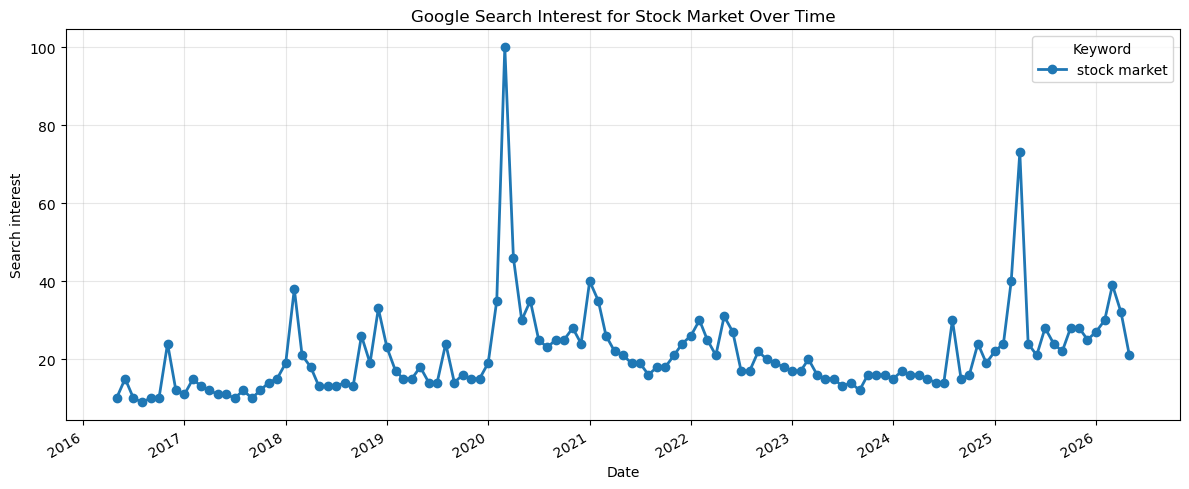

,date,keyword,interest
0,2016-05-01,stock market,10
1,2016-06-01,stock market,15
2,2016-07-01,stock market,10
3,2016-08-01,stock market,9
4,2016-09-01,stock market,10


In [ ]:
# Load stock market trends data
stock_trends = pd.read_csv('stock_market_trends.csv', parse_dates=['date'])
stock_trends = stock_trends.sort_values('date')

# Plotting search interest over time
fig, ax = plt.subplots(figsize=(12, 5))

for keyword, keyword_data in stock_trends.groupby('keyword'):
    ax.plot(keyword_data['date'], keyword_data['interest'], marker='o', linewidth=2, label=keyword)

ax.set_title('Google Search Interest for Stock Market Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Search interest')
ax.grid(True, alpha=0.3)
ax.legend(title='Keyword')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

stock_trends.head()

The word "stock market" looks stable overall with a 2 large spikes. One near COVID and another near the beginning of 2025, potentially due to tariffs. We pursue this further and double check that the data is stationary and stable.

=== Descriptive Stats by Sub-Period ===
             Mean    Std  Min  Max    CV
period                                  
Pre-COVID   15.67   6.00    9   38  0.38
COVID       32.88  18.77   19  100  0.57
Post-COVID  21.95   9.21   12   73  0.42


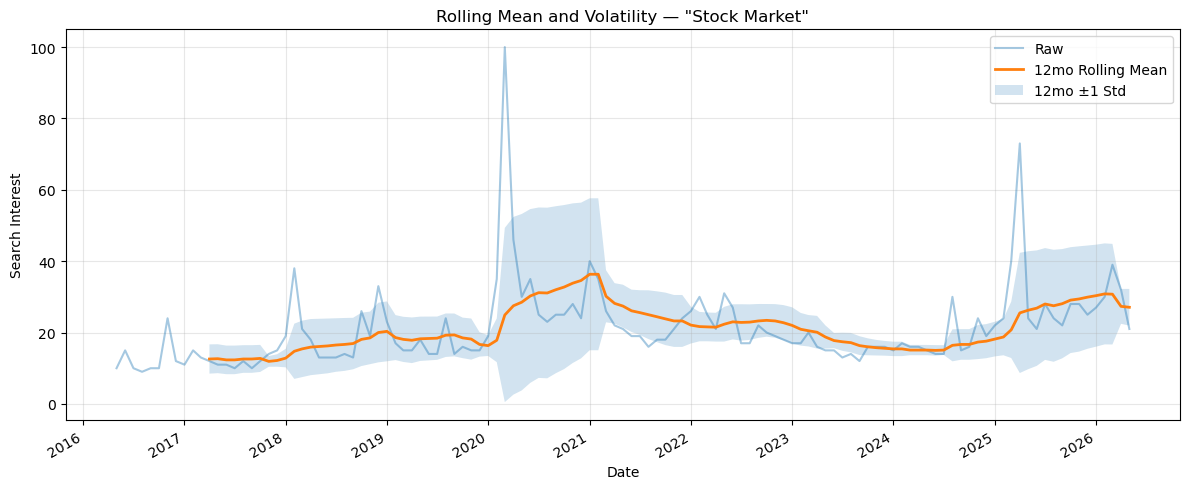

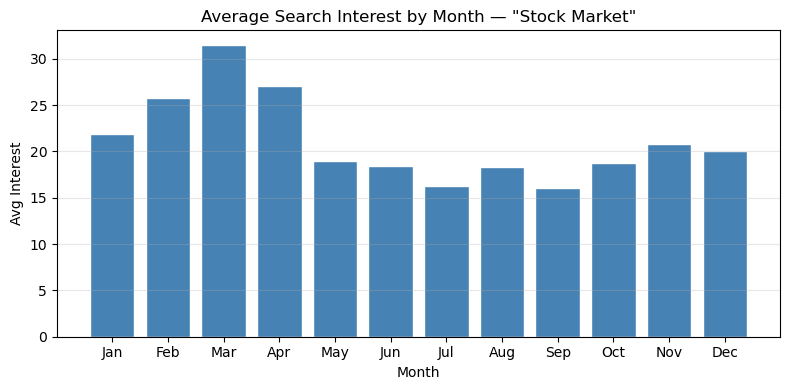


=== Spikes (> mean + 2σ) ===
      date  interest
2020-03-01       100
2020-04-01        46
2025-04-01        73

=== ADF Test (H0: unit root / non-stationary) ===
  ADF Statistic : -6.1742
  p-value       : 0.0000
  Reject H0     : True

=== KPSS Test (H0: stationary) ===
  KPSS Statistic: 0.4083
  p-value       : 0.0736
  Reject H0     : False


In [5]:
# Use the interest series directly
series = stock_trends['interest']
dates = stock_trends['date']

# Descriptive stats by sub-periods based on COVID and previous time series above
stock_trends['period'] = pd.cut(stock_trends['date'],
    bins=[pd.Timestamp('2016-01-01'), pd.Timestamp('2020-01-01'),
          pd.Timestamp('2021-06-01'), pd.Timestamp('2026-12-31')],
    labels=['Pre-COVID', 'COVID', 'Post-COVID'])

desc = stock_trends.groupby('period', observed=True)['interest'].agg(
    Mean='mean', Std='std', Min='min', Max='max',
    CV=lambda x: x.std() / x.mean()
).round(2)

print("=== Descriptive Stats by Sub-Period ===")
print(desc)

# Rolling-mean and std figure
window = 12

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(dates, series, alpha=0.4, label='Raw', linewidth=1.5)
ax.plot(dates, series.rolling(window).mean(), label=f'{window}mo Rolling Mean', linewidth=2)
ax.fill_between(dates,
    series.rolling(window).mean() - series.rolling(window).std(),
    series.rolling(window).mean() + series.rolling(window).std(),
    alpha=0.2, label=f'{window}mo ±1 Std')
ax.set_title('Rolling Mean and Volatility — "Stock Market"')
ax.set_xlabel('Date')
ax.set_ylabel('Search Interest')
ax.legend()
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Seasonality check: average interest by month
stock_trends['month'] = stock_trends['date'].dt.month
monthly_avg = stock_trends.groupby('month')['interest'].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(monthly_avg.index, monthly_avg.values, color='steelblue', edgecolor='white')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_title('Average Search Interest by Month — "Stock Market"')
ax.set_xlabel('Month')
ax.set_ylabel('Avg Interest')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Checking for spikes: points where interest > mean + 2*std
mean, std = series.mean(), series.std()
spikes = stock_trends[series > mean + 2 * std][['date', 'interest']]
print("\n=== Spikes (> mean + 2σ) ===")
print(spikes.to_string(index=False))

# Formal stationarity tests
print("\n=== ADF Test (H0: unit root / non-stationary) ===")
adf_result = adfuller(series.dropna())
print(f"  ADF Statistic : {adf_result[0]:.4f}")
print(f"  p-value       : {adf_result[1]:.4f}")
print(f"  Reject H0     : {adf_result[1] < 0.05}")

print("\n=== KPSS Test (H0: stationary) ===")
kpss_result = kpss(series.dropna(), regression='c', nlags='auto')
print(f"  KPSS Statistic: {kpss_result[0]:.4f}")
print(f"  p-value       : {kpss_result[1]:.4f}")
print(f"  Reject H0     : {kpss_result[1] < 0.05}")

### Descriptive Stats
Based on plotting search interest over time, I examine descriptive stats across three sub-periods: Pre-COVID (2016–2019), COVID (2020–mid-2021), and Post-COVID (mid-2021–present). As expected, mean interest is highest during COVID (32.88) compared to Pre-COVID (15.67) and Post-COVID (21.95). Volatility follows the same pattern, with the COVID period having the highest std (18.77) and CV (0.57), while Pre-COVID is the most stable (std = 6.00, CV = 0.38). Post-COVID settles in between, suggesting some persistently elevated interest in markets relative to the pre-pandemic baseline.

### Rolling Mean and Vol
The rolling mean and volatility plot gives a clearer picture of the series behavior compared to the raw plot. The rolling mean stays roughly between 15–25 outside of shock periods, confirming that "stock market" is not very volatile and remains stable over time. The elevated uncertainty band around the COVID period is visually clear but short-lived, with the series quickly reverting to its pre-shock range.

### Seasonality
Taking the average interest by month and plotting it as a bar chart, we find that March and April have the highest averages. This makes sense given Q1 earnings season and tax season, though COVID likely skews these two months upward as well. As a robustness check, it may be worth re-examining seasonality excluding 2020 to isolate the structural seasonal pattern from event-driven noise. Summer months are notably calmer, with June, July, and August showing the lowest averages, which is consistent with lower market activity during that period.

### Spikes
Formally checking for spikes by identifying observations exceeding mean + 2σ, we find only 3 spikes over roughly 10 years, which is overall clean and stable. Two of the three occur in March and April 2020, driven by the COVID-19 market crash. The third is April 2025, likely reflecting elevated policy uncertainty surrounding the new administration's trade policy and broader macroeconomic concerns at that time. 

### Stationarity
We formally test the stability of the series using two complementary stationarity tests. The ADF test, which tests the null hypothesis of a unit root, rejects with p < 0.001, confirming the series is stationary. The KPSS test, which tests the null of stationarity, fails to reject with p = 0.074. Together these two results provide strong evidence that the series is stationary and stable over the full sample period, meaning we can use levels directly in our models without differencing. 